<a href="https://colab.research.google.com/github/shaunyttan-cell/MDS5023_SHAUN_TAN_YAN_TAT_25119033/blob/main/MDA5013_25119033_Shaun_Tan_Yan_Tat_Assessment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import os

print("Go to Kaggle → Settings → API Tokens → Generate New Token")
print("Copy the code block shown there and paste it below.")

username = input("KAGGLE_USERNAME: ")
key = input("KAGGLE_KEY: ")

# Create the kaggle.json file manually
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write(f'{{"username":"{username}","key":"{key}"}}')

!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

print("Kaggle API configured successfully.")

Go to Kaggle → Settings → API Tokens → Generate New Token
Copy the code block shown there and paste it below.
KAGGLE_USERNAME: User_Name
KAGGLE_KEY: KEY
Kaggle API configured successfully.


In [2]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:14<00:00, 18.4MB/s]



In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, GlobalAveragePooling2D)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score)
from sklearn.utils import class_weight

In [4]:
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [37]:
# Global configuration
img_size   = (224, 224)   # VGG16 expects 224x224; we use the same for the
                          # conventional CNN so the comparison is fair.
Batch_size = 128
Epochs = 30           # EarlyStopping will usually halt before this.
lr = 1e-4         # Conservative learning rate.

In [6]:
# Fix random seeds so results are reproducible across runs
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
#Validate directory

data_dir = "chest_xray"
for split in ["train", "test", "val"]:
    split_total = 0
    print(f"\n{split.upper()}/")
    for cls in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(data_dir, split, cls)
        count = len(os.listdir(path))
        split_total += count
        print(f"  {cls}: {count} images")
    print(f"  Subtotal: {split_total}")


TRAIN/
  NORMAL: 1341 images
  PNEUMONIA: 3875 images
  Subtotal: 5216

TEST/
  NORMAL: 234 images
  PNEUMONIA: 390 images
  Subtotal: 624

VAL/
  NORMAL: 8 images
  PNEUMONIA: 8 images
  Subtotal: 16


In [8]:
#Check directory nesting structure

!find . -name "NORMAL" -type d

./chest_xray/chest_xray/test/NORMAL
./chest_xray/chest_xray/train/NORMAL
./chest_xray/chest_xray/val/NORMAL
./chest_xray/test/NORMAL
./chest_xray/train/NORMAL
./chest_xray/val/NORMAL
./chest_xray/__MACOSX/chest_xray/test/NORMAL
./chest_xray/__MACOSX/chest_xray/train/NORMAL
./chest_xray/__MACOSX/chest_xray/val/NORMAL


In [9]:
# Remove the nested duplicate
import shutil
shutil.rmtree("chest_xray/chest_xray", ignore_errors=True)
shutil.rmtree("chest_xray/__MACOSX", ignore_errors=True)

In [10]:
#Check directory nesting structure

data_dir = "chest_xray"
for split in ["train", "test", "val"]:
    split_total = 0
    print(f"\n{split.upper()}/")
    for cls in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(data_dir, split, cls)
        count = len(os.listdir(path))
        split_total += count
        print(f"  {cls}: {count} images")
    print(f"  Subtotal: {split_total}")


TRAIN/
  NORMAL: 1341 images
  PNEUMONIA: 3875 images
  Subtotal: 5216

TEST/
  NORMAL: 234 images
  PNEUMONIA: 390 images
  Subtotal: 624

VAL/
  NORMAL: 8 images
  PNEUMONIA: 8 images
  Subtotal: 16


In [11]:
# 1. DATA PREPROCESSING

# Directory Setup

train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")

print(f" train data directory: {train_dir}")
print(f" test data directory: {test_dir}")



 train data directory: chest_xray/train
 test data directory: chest_xray/test


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

# 1. Native dataset loaders
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='binary',
    validation_split=0.20, subset="training", seed=SEED,
    image_size=img_size, batch_size=Batch_size
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='binary',
    validation_split=0.20, subset="validation", seed=SEED,
    image_size=img_size, batch_size=Batch_size
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='binary',
    image_size=img_size, batch_size=Batch_size, shuffle=False
)

# Augmentation pipeline — defined once, applied ONLY to training data.
# Keeping it in the data pipeline (not inside the model) guarantees it
# never runs during validation, testing, or prediction.
data_augmentation = Sequential([
    RandomRotation(0.04),
    RandomTranslation(height_factor=0.1, width_factor=0.1),
    RandomZoom(0.1),
    RandomFlip("horizontal")
], name="data_augmentation")

def optimize_dataset(ds, training=False, cache=False):
    normalization_layer = tf.keras.layers.Rescaling(1./255)
    # Normalise all datasets
    ds = ds.map(lambda x, y: (normalization_layer(x), y),
                num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    # Apply augmentation ONLY to the training set, AFTER caching so each
    # epoch sees freshly augmented images rather than cached fixed ones.
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

# training=True only for the training set
train_dataset = optimize_dataset(train_dataset, training=True, cache=True)
val_dataset   = optimize_dataset(val_dataset,   training=False, cache=True)
test_dataset  = optimize_dataset(test_dataset,  training=False, cache=True)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


In [15]:
# Compute class weights to handle the imbalance in the loss function.
# This penalises misclassifying the minority class (NORMAL) more heavily, so the model cannot simply exploit the majority class.

print("Extracting labels to compute class weights...")

# .flatten() is the fix here! It squashes [[1.], [0.]] into [1, 0]
y_train = np.concatenate([y for x, y in train_dataset], axis=0).flatten().astype(int)
classes = np.unique(y_train)

# Compute the weights
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))

print("Computed class weights:", class_weights)

Extracting labels to compute class weights...
Computed class weights: {np.int64(0): np.float64(1.9107142857142858), np.int64(1): np.float64(0.6772151898734177)}


In [16]:
# Build Conventional CNN from scratch.
# Three convolutional blocks (Conv -> MaxPool) with increasing filters, followed by a dense head with dropout.

# Conventional CNN built from scratch.
# Three convolutional blocks (Conv -> MaxPool) with increasing filters,
# followed by a dense head with dropout. Augmentation is handled in the
# data pipeline, so it is NOT included here.

def build_conventional_cnn(input_shape=(224, 224, 3)):
    model = Sequential([
        tf.keras.Input(shape=input_shape),

        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid", dtype='float32')  # float32 for mixed precision
    ], name="Conventional_CNN")

    return model

In [22]:
# Pre-trained VGG16 (transfer learning).
# Load VGG16 with ImageNet weights, WITHOUT its top classifier.
# Freeze the convolutional base (feature extractor) and attach a new head.
# This follows the standard feature-extraction approach for adapting a pre-trained network to a small medical dataset.

def build_vgg16_transfer(input_shape=(224, 224, 3)):
    base = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation="sigmoid", dtype='float32')(x)   # ← added (x)

    model = Model(inputs=inputs, outputs=output, name="VGG16_Transfer")
    return model

In [24]:
cnn_model = build_conventional_cnn()
cnn_model.compile(optimizer=Adam(learning_rate=lr),
                  loss="binary_crossentropy", metrics=["accuracy"])

vgg_model = build_vgg16_transfer()
vgg_model.compile(optimizer=Adam(learning_rate=lr),
                  loss="binary_crossentropy", metrics=["accuracy"])

print("\n--- Conventional CNN architecture ---")
cnn_model.summary()
print("\n--- VGG16 transfer architecture ---")
vgg_model.summary()


--- Conventional CNN architecture ---


Model: "Conventional_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

...

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [25]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [39]:
# EarlyStopping halts training when validation loss stops improving and restores the best weights.

def make_callbacks(tag, patience=6):
    return [
        EarlyStopping(monitor="val_loss", patience=patience,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f"best_{tag}.keras", monitor="val_loss",
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                          min_lr=1e-6, verbose=1)
    ]

# --- Conventional CNN ---
print("\n=== Training Conventional CNN ===")
cnn_model = build_conventional_cnn()
cnn_model.compile(optimizer=Adam(learning_rate=lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
cnn_history = cnn_model.fit(
    train_dataset, validation_data=val_dataset, epochs=Epochs,
    class_weight=class_weights, callbacks=make_callbacks("cnn", patience=6),
    verbose=1
)

# --- VGG16 feature extraction (more epochs + patience so it converges) ---
print("\n=== Training VGG16 Transfer Model (feature extraction) ===")
vgg_model = build_vgg16_transfer()
vgg_model.compile(optimizer=Adam(learning_rate=lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
vgg_history = vgg_model.fit(
    train_dataset, validation_data=val_dataset, epochs=Epochs,
    class_weight=class_weights, callbacks=make_callbacks("vgg", patience=8),
    verbose=1
)


=== Training Conventional CNN ===
Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 256ms/step - accuracy: 0.5739 - loss: 0.6727 - val_accuracy: 0.3164 - val_loss: 0.7360 - learning_rate: 1.0000e-04
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step - accuracy: 0.7191 - loss: 0.5557 - val_accuracy: 0.5484 - val_loss: 0.7439 - learning_rate: 1.0000e-04
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 225ms/step - accuracy: 0.8054 - loss: 0.4322 - val_accuracy: 0.5129 - val_loss: 0.9665 - learning_rate: 1.0000e-04
Epoch 4/30
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8441 - loss: 0.3683
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - accuracy: 0.8545 - loss: 0.3568 - val_accuracy: 0.6520 - val_loss: 0.7999 - learning_rate: 1.0000e-04
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - accuracy: 0.8675 - loss: 0.3198 - val_accuracy: 0.6683 - val_loss: 0.7816 - learning_rate: 5.0000e-05
Epoch 6/30
33/33 ━━━━━━━━━━━━

In [40]:
def evaluate_model(model, dataset, name):
    # tf.data.Dataset does not need .reset()
    probs = model.predict(dataset, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)

    # Extract true labels from the dataset (order is preserved because shuffle=False on test_dataset)
    y_true = np.concatenate([y for x, y in dataset], axis=0).flatten().astype(int)

    acc  = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds)     # positive class = PNEUMONIA
    rec  = recall_score(y_true, preds)        # PRIMARY metric (clinical focus)
    f1   = f1_score(y_true, preds)            # SECONDARY metric

    print(f"\n----- {name} -----")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall   : {rec*100:.2f}%   <-- primary metric")
    print(f"F1-score : {f1*100:.2f}%   <-- secondary metric")
    print("\nFull classification report:")
    print(classification_report(y_true, preds,
                                target_names=["NORMAL", "PNEUMONIA"]))

    return {"name": name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "y_true": y_true, "preds": preds}

# Use test_dataset instead of test_generator
cnn_results = evaluate_model(cnn_model, test_dataset, "Conventional CNN")
vgg_results = evaluate_model(vgg_model, test_dataset, "VGG16 Transfer")


----- Conventional CNN -----
Accuracy : 87.02%
Precision: 91.64%
Recall   : 87.18%   <-- primary metric
F1-score : 89.36%   <-- secondary metric

Full classification report:
              precision    recall  f1-score   support

      NORMAL       0.80      0.87      0.83       234
   PNEUMONIA       0.92      0.87      0.89       390

    accuracy                           0.87       624
   macro avg       0.86      0.87      0.86       624
weighted avg       0.87      0.87      0.87       624


----- VGG16 Transfer -----
Accuracy : 79.01%
Precision: 92.74%
Recall   : 72.05%   <-- primary metric
F1-score : 81.10%   <-- secondary metric

Full classification report:
              precision    recall  f1-score   support

      NORMAL       0.66      0.91      0.76       234
   PNEUMONIA       0.93      0.72      0.81       390

    accuracy                           0.79       624
   macro avg       0.79      0.81      0.79       624
weighted avg       0.83      0.79      0.79       624

In [41]:
print("\n=== Fine-tuning VGG16 (unfreezing top convolutional layers) ===")

# Unfreeze the last 4 layers of the VGG16 base for fine-tuning.
for layer in vgg_model.layers[-6:]:   # last 4 conv layers + new head layers
    layer.trainable = True

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg_finetune_history = vgg_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=make_callbacks("vgg_finetuned"),
    verbose=1
)

# Use test_dataset instead of test_generator
vgg_results_finetuned = evaluate_model(
    vgg_model, test_dataset, "VGG16 Transfer (Fine-tuned)"
)


=== Fine-tuning VGG16 (unfreezing top convolutional layers) ===
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 400ms/step - accuracy: 0.9142 - loss: 0.2233 - val_accuracy: 0.7430 - val_loss: 0.6345 - learning_rate: 1.0000e-05
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 280ms/step - accuracy: 0.9324 - loss: 0.1647 - val_accuracy: 0.7776 - val_loss: 0.5746 - learning_rate: 1.0000e-05
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 276ms/step - accuracy: 0.9528 - loss: 0.1218 - val_accuracy: 0.8245 - val_loss: 0.4967 - learning_rate: 1.0000e-05
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step - accuracy: 0.9518 - loss: 0.1159 - val_accuracy: 0.8303 - val_loss: 0.4967 - learning_rate: 1.0000e-05
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.9612 - loss: 0.1049 - val_accuracy: 0.8121 - val_loss: 0.5482 - learning_rate: 1.0000e-05
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 282ms/step - accuracy: 0.9561 - loss: 0.1071 - val_accuracy: 0.8859 - val_loss: 0.2933 - learning_rate: 1.00

In [42]:
print("\n=== Conventional CNN: testing higher learning rate (1e-3) ===")

# Rebuild from scratch to ensure a fair comparison
cnn_model_lr_high = build_conventional_cnn()
cnn_model_lr_high.compile(
    optimizer=Adam(learning_rate=1e-3),   # 10x higher than baseline
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history_lr_high = cnn_model_lr_high.fit(
    train_dataset,                 # Changed from train_generator
    validation_data=val_dataset,   # Changed from val_generator
    epochs=Epochs,
    class_weight=class_weights,
    callbacks=make_callbacks("cnn_lr_high"),
    verbose=1
)

# Use test_dataset instead of test_generator
cnn_results_lr_high = evaluate_model(
    cnn_model_lr_high, test_dataset, "Conventional CNN (LR=1e-3)"
)

# Print direct comparison between the two learning rate configurations
print("\n----- Learning rate comparison (Conventional CNN) -----")
print(f"{'Configuration':<25}{'Recall':<10}{'F1-Score':<10}")
print(f"{'LR = 1e-4 (baseline)':<25}{cnn_results['recall']*100:<10.2f}{cnn_results['f1']*100:<10.2f}")
print(f"{'LR = 1e-3 (tested)':<25}{cnn_results_lr_high['recall']*100:<10.2f}{cnn_results_lr_high['f1']*100:<10.2f}")

# Pick the better of the two for the final comparison
if cnn_results_lr_high["f1"] > cnn_results["f1"]:
    print("→ Higher learning rate selected for final comparison.")
    cnn_final_results = cnn_results_lr_high
else:
    print("→ Baseline learning rate retained for final comparison.")
    cnn_final_results = cnn_results


=== Conventional CNN: testing higher learning rate (1e-3) ===
Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 253ms/step - accuracy: 0.4589 - loss: 0.8183 - val_accuracy: 0.2905 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step - accuracy: 0.6183 - loss: 0.6486 - val_accuracy: 0.6711 - val_loss: 0.6201 - learning_rate: 0.0010
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.7419 - loss: 0.5085 - val_accuracy: 0.8274 - val_loss: 0.3959 - learning_rate: 0.0010
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.8529 - loss: 0.3513 - val_accuracy: 0.8619 - val_loss: 0.3069 - learning_rate: 0.0010
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - accuracy: 0.8795 - loss: 0.3046 - val_accuracy: 0.6663 - val_loss: 0.6913 - learning_rate: 0.0010
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 261ms/step - accuracy: 0.8684 - loss: 0.3028 - val_accuracy: 0.9070 - val_loss: 0.2575 - learning_rate: 0.0010
Epoch 7/30
33/33 ━━

In [47]:
print("\n--- VGG16 transfer architecture (after fine-tuning) ---")
vgg_model.summary()


--- VGG16 transfer architecture (after fine-tuning) ---


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,341,449 (169.15 MB)

 Trainable params: 14,780,481 (56.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,560,968 (112.77 MB)

In [48]:
# MODEL COMPARISON
# ---------------------------------------------------------------------------
# 5a. Metrics table -> copy these numbers into Table 1 of the report.

print("\n================ METRIC COMPARISON ================")
print(f"{'Metric':<12}{'Conventional CNN':<20}{'VGG16 Fine-tuned':<20}")
for m in ["accuracy", "precision", "recall", "f1"]:
    print(f"{m.capitalize():<12}{cnn_final_results[m]*100:<20.2f}{vgg_results_finetuned[m]*100:<20.2f}")


================ METRIC COMPARISON ================
Metric      Conventional CNN    VGG16 Fine-tuned    
Accuracy    87.02               92.63               
Precision   91.64               92.79               
Recall      87.18               95.64               
F1          89.36               94.19               


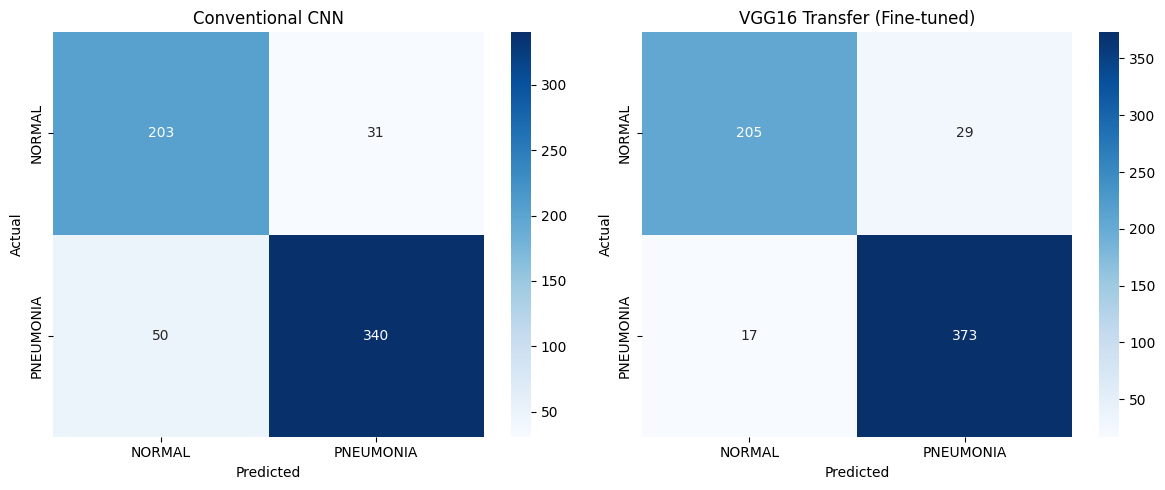

In [44]:
# Confusion matrices -> Figure 1 in the report.

def plot_confusion(ax, res):
    cm = confusion_matrix(res["y_true"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["NORMAL", "PNEUMONIA"],
                yticklabels=["NORMAL", "PNEUMONIA"])
    ax.set_title(res["name"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion(axes[0], cnn_final_results)
plot_confusion(axes[1], vgg_results_finetuned)     # fine-tuned, not frozen
plt.tight_layout()
plt.savefig("figure_confusion_matrices.png", dpi=150)
plt.show()

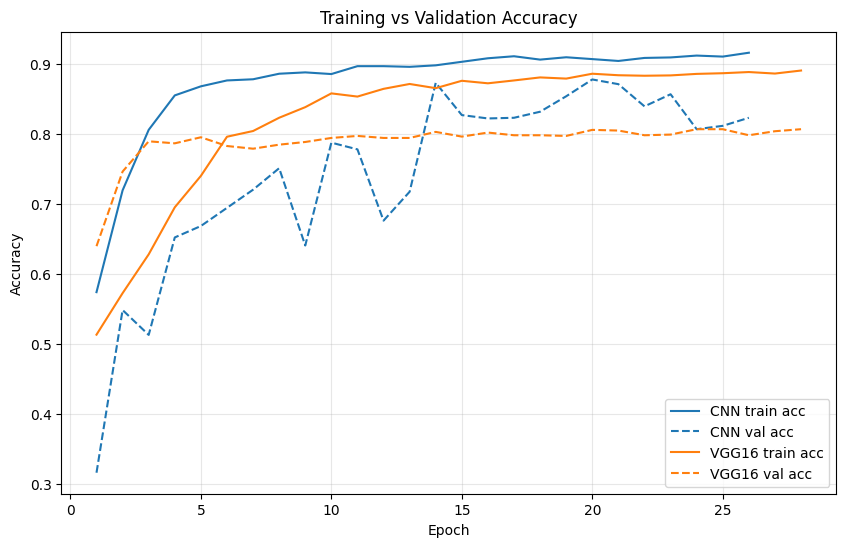

In [45]:
# ---------------------------------------------------------------------------
# 5c. Training/validation curves -> Figure 2 in the report.
# ---------------------------------------------------------------------------
def plot_history(history, name, color):
    epochs_ran = range(1, len(history.history["accuracy"]) + 1)
    plt.plot(epochs_ran, history.history["accuracy"],
             color=color, linestyle="-", label=f"{name} train acc")
    plt.plot(epochs_ran, history.history["val_accuracy"],
             color=color, linestyle="--", label=f"{name} val acc")

plt.figure(figsize=(10, 6))
plot_history(cnn_history, "CNN", "tab:blue")
plot_history(vgg_history, "VGG16", "tab:orange")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("figure2_training_curves.png", dpi=150)
plt.show()

In [46]:
# ===========================================================================
# 6. CONCLUSION  (printed summary to anchor the report's conclusion)
# ===========================================================================
winner = "VGG16 Transfer" if vgg_results["recall"] > cnn_results["recall"] \
         else "Conventional CNN"
print("\n==================== SUMMARY ====================")
print(f"{'Model':<32}{'Recall':<10}{'F1':<10}{'Accuracy':<10}")
print(f"{'Conventional CNN (best)':<32}{cnn_final_results['recall']*100:<10.2f}{cnn_final_results['f1']*100:<10.2f}{cnn_final_results['accuracy']*100:<10.2f}")
print(f"{'VGG16 (feature extraction)':<32}{vgg_results['recall']*100:<10.2f}{vgg_results['f1']*100:<10.2f}{vgg_results['accuracy']*100:<10.2f}")
print(f"{'VGG16 (fine-tuned)':<32}{vgg_results_finetuned['recall']*100:<10.2f}{vgg_results_finetuned['f1']*100:<10.2f}{vgg_results_finetuned['accuracy']*100:<10.2f}")

best_recall = max(
    ("Conventional CNN", cnn_final_results["recall"]),
    ("VGG16 fine-tuned", vgg_results_finetuned["recall"]),
    key=lambda t: t[1]
)
print(f"\nHighest recall (primary clinical metric): {best_recall[0]} ({best_recall[1]*100:.2f}%)")
print(f"Best overall F1: VGG16 fine-tuned ({vgg_results_finetuned['f1']*100:.2f}%)")


==================== SUMMARY ====================
Model                           Recall    F1        Accuracy  
Conventional CNN (best)         87.18     89.36     87.02     
VGG16 (feature extraction)      72.05     81.10     79.01     
VGG16 (fine-tuned)              95.64     94.19     92.63     

Highest recall (primary clinical metric): VGG16 fine-tuned (95.64%)
Best overall F1: VGG16 fine-tuned (94.19%)
